In [2]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
# Load Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
df = pd.read_csv(url, sep='\s+', header=None)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3520536282.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', header=None)


In [6]:
#select features
X = df.iloc[:,:-1] #use all except the last column (label)

In [15]:
# standard scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# create linkage matrix
linked = linkage(X_scaled, method='ward')

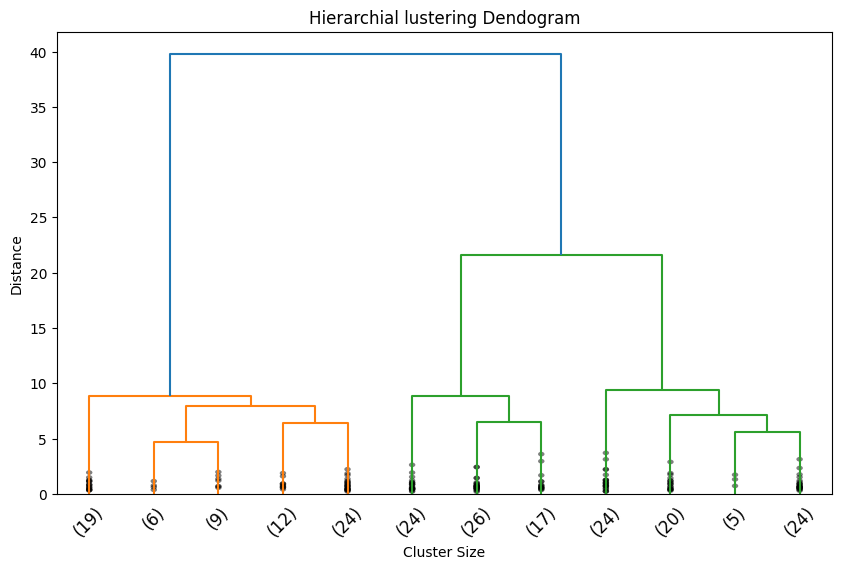

In [35]:
#plot dendogram
plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='lastp', p =12, leaf_rotation= 45, leaf_font_size= 12, show_contracted=True)
plt.title('Hierarchial lustering Dendogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

In [36]:
# apply flat clustering (cut tree)
num_clusters = 3
cluster_labels = fcluster(linked, num_clusters, criterion='maxclust')

In [37]:
#evaluating silhoutte score
score = silhouette_score(X_scaled, cluster_labels)
print(f'Silhoutte Score:{score:.3f}')

Silhoutte Score:0.393


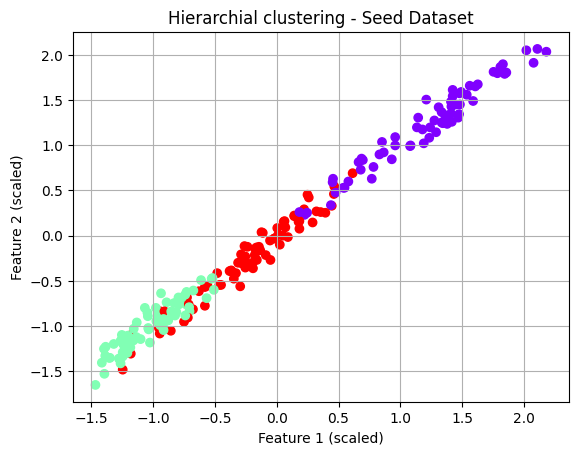

In [39]:
#visualizing final clusters (using first 2 features)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c= cluster_labels, cmap='rainbow')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Hierarchial clustering - Seed Dataset')
plt.grid(True)
plt.show()